In [1]:
!pip install opencv-python numpy matplotlib scikit-learn scikit-image seaborn

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skimage.feature import hog
from skimage import color
import seaborn as sns

warnings.filterwarnings("ignore")
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# 'r' lagane se Windows ka backslash path error nahi dega
DATASET_PATH = r"C:\Users\bkhal\Downloads\cats_dogs_light\cats_dogs_light"

cat_dir = os.path.join(DATASET_PATH, "cat")
dog_dir = os.path.join(DATASET_PATH, "dogs")

# Verify directories exist
if not os.path.exists(cat_dir) or not os.path.exists(dog_dir):
    print("❌ Error: Path sahi nahi hai! Ek baar apna folder structure check karein.")
else:
    cat_imgs = os.listdir(cat_dir)
    dog_imgs = os.listdir(dog_dir)

    print(f"Total Cat images : {len(cat_imgs)}")
    print(f"Total Dog images : {len(dog_imgs)}")
    print(f"Total images : {len(cat_imgs) + len(dog_imgs)}")

    # Show sample image details
    sample = cv2.imread(os.path.join(cat_dir, cat_imgs[0]))
    if sample is not None:
        print(f"Sample image shape : {sample.shape}")
    else:
        print("❌ Image load nahi ho saki. Path check karein.")

❌ Error: Path sahi nahi hai! Ek baar apna folder structure check karein.


NameError: name 'cat_imgs' is not defined

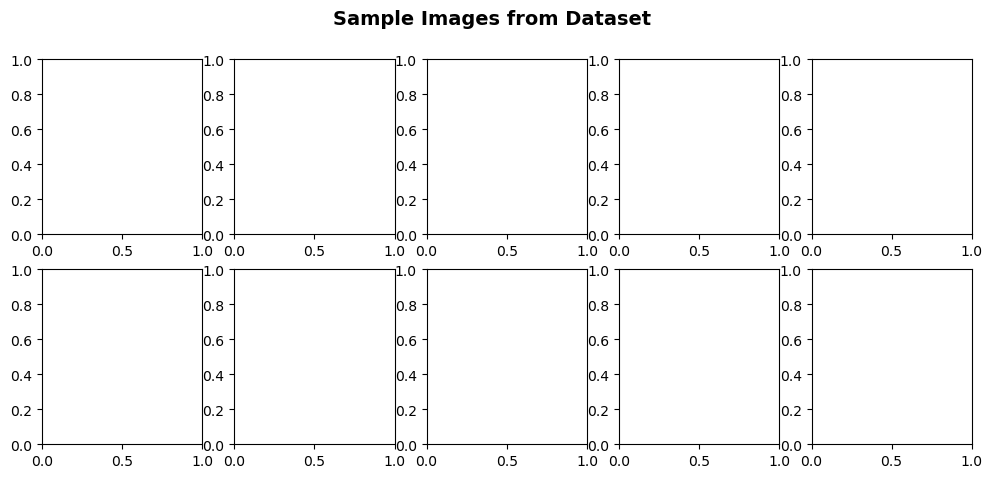

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images from Dataset", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes[0]):
    img = cv2.imread(os.path.join(cat_dir, cat_imgs[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Cat")
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    img = cv2.imread(os.path.join(dog_dir, dog_imgs[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title("Dog")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
IMG_SIZE = (64, 64)
USE_GRAY = False  # True for grayscale, False for RGB

def preprocess_image(path, size=IMG_SIZE, gray=USE_GRAY):
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.resize(img, size)
    if gray:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    return img

# Quick test
test_img = preprocess_image(os.path.join(cat_dir, cat_imgs[0]))
print(f"Preprocessed shape : {test_img.shape}")
print(f"Pixel range : [{test_img.min():.2f}, {test_img.max():.2f}]")

NameError: name 'cat_imgs' is not defined

In [6]:
def extract_hog_features(img):
    if img.ndim == 3:
        gray = color.rgb2gray(img)
    else:
        gray = img
        
    features = hog(gray,
                   orientations=9,
                   pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2),
                   block_norm='L2-Hys',
                   visualize=False)
    return features

sample_feat = extract_hog_features(test_img)
print(f"HOG feature vector length: {len(sample_feat)}")

NameError: name 'test_img' is not defined

In [7]:
gray_img = color.rgb2gray(test_img)
fd, hog_img = hog(gray_img, visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(test_img)
ax1.set_title("Original")
ax2.imshow(hog_img, cmap="magma")
ax2.set_title("HOG Descriptor")
for ax in [ax1, ax2]:
    ax.axis("off")
plt.tight_layout()
plt.show()

NameError: name 'test_img' is not defined

In [8]:
MAX_PER_CLASS = 2000  # Aap isko adjust kar sakte hain agar computer slow ho
X = []
y = []

print("--- Extracting features from dataset subset ---")
for label, folder in [(0, cat_dir), (1, dog_dir)]:
    imgs = os.listdir(folder)[:MAX_PER_CLASS]
    for fname in imgs:
        path = os.path.join(folder, fname)
        img = preprocess_image(path)
        if img is None:
            continue
        X.append(extract_hog_features(img))
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Feature matrix shape : {X.shape}")
print(f"Labels shape : {y.shape}")

# Train vs Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("✅ Feature scaling done.")

--- Extracting features from dataset subset ---


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\bkhal\\Downloads\\cats_dogs_light\\cats_dogs_light\\cat'

In [9]:
# Linear SVM
print("Training Linear SVM...")
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, pred_linear)
print(f"Linear SVM Accuracy: {acc_linear * 100:.2f}%")

# RBF SVM
print("\nTraining RBF SVM...")
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_train, y_train)
pred_rbf = svm_rbf.predict(X_test)
acc_rbf = accuracy_score(y_test, pred_rbf)
print(f"RBF SVM Accuracy: {acc_rbf * 100:.2f}%")

# Polynomial SVM
print("\nTraining Polynomial SVM...")
svm_poly = SVC(kernel="poly", C=1.0, degree=3, random_state=42)
svm_poly.fit(X_train, y_train)
pred_poly = svm_poly.predict(X_test)
acc_poly = accuracy_score(y_test, pred_poly)
print(f"Polynomial SVM Accuracy: {acc_poly * 100:.2f}%")

Training Linear SVM...


NameError: name 'X_train' is not defined

In [10]:
print("\n" + "="*50)
print("Classification Report - RBF SVM")
print("="*50)
print(classification_report(y_test, pred_rbf, target_names=["Cat", "Dog"]))

# Heatmap
cm_rbf = confusion_matrix(y_test, pred_rbf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_rbf, annot=True, fmt="d",
            cmap="Purples", xticklabels=["Cat", "Dog"],
            yticklabels=["Cat", "Dog"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - RBF SVM")
plt.tight_layout()
plt.show()


Classification Report - RBF SVM


NameError: name 'y_test' is not defined

In [11]:
kernels = ["Linear", "RBF", "Polynomial"]
accs = [acc_linear*100, acc_rbf*100, acc_poly*100]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(kernels, accs, color=["#6366F1", "#8B5CF6", "#A78BFA"])
ax.set_ylim(min(accs) - 5, max(accs) + 5) # Dynamic scaling
ax.set_ylabel("Accuracy (%)")
ax.set_title("SVM Kernel Comparison")

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{acc:.1f}%", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

NameError: name 'acc_linear' is not defined